<a href="https://colab.research.google.com/github/Krishna-Dhawangale/Resume-Screening-Machine-Learning-/blob/main/CatBoost(Resume_Screening).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
path="/content/drive/MyDrive/ML_Data/AI_Resume_Screening.csv"
df=pd.read_csv(path)
df.head(5)

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Resume_ID               1000 non-null   int64 
 1   Name                    1000 non-null   object
 2   Skills                  1000 non-null   object
 3   Experience (Years)      1000 non-null   int64 
 4   Education               1000 non-null   object
 5   Certifications          726 non-null    object
 6   Job Role                1000 non-null   object
 7   Recruiter Decision      1000 non-null   object
 8   Salary Expectation ($)  1000 non-null   int64 
 9   Projects Count          1000 non-null   int64 
 10  AI Score (0-100)        1000 non-null   int64 
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [5]:
df.shape

(1000, 11)

In [6]:
df.describe()

,Resume_ID,Experience (Years),Salary Expectation ($),Projects Count,AI Score (0-100)
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,500.500000,4.896000,79994.486000,5.13300,83.950000
std,288.819436,3.112695,23048.472549,3.23137,20.983036
min,1.000000,0.000000,40085.000000,0.00000,15.000000
25%,250.750000,2.000000,60415.750000,2.00000,70.000000
50%,500.500000,5.000000,79834.500000,5.00000,100.000000
75%,750.250000,8.000000,99583.250000,8.00000,100.000000
max,1000.000000,10.000000,119901.000000,10.00000,100.000000


In [7]:
df.columns

Index(['Resume_ID', 'Name', 'Skills', 'Experience (Years)', 'Education',
       'Certifications', 'Job Role', 'Recruiter Decision',
       'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)'],
      dtype='object')

In [8]:
df.isnull().any().any()

np.True_

In [9]:
df.isnull().sum()

,0
Resume_ID,0
Name,0
Skills,0
Experience (Years),0
Education,0
Certifications,274
Job Role,0
Recruiter Decision,0
Salary Expectation ($),0
Projects Count,0


In [10]:
df['Certifications'].fillna('No Certification', inplace=True)
df['Certifications'].isnull().sum()

/tmp/ipykernel_14147/67032770.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Certifications'].fillna('No Certification', inplace=True)


np.int64(0)

In [11]:
df.isnull().sum()

,0
Resume_ID,0
Name,0
Skills,0
Experience (Years),0
Education,0
Certifications,0
Job Role,0
Recruiter Decision,0
Salary Expectation ($),0
Projects Count,0


In [12]:
#print missing value
df[df.isnull().any(axis=1)]

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)


In [13]:
df.drop('number', axis=1, inplace=True, errors='ignore')
df.columns

Index(['Resume_ID', 'Name', 'Skills', 'Experience (Years)', 'Education',
       'Certifications', 'Job Role', 'Recruiter Decision',
       'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)'],
      dtype='object')

In [14]:
df.shape

(1000, 11)

In [15]:
clean_data = df.copy()

In [16]:
# Drop both 'Recruiter Decision' and 'AI Score (0-100)' from features
X = clean_data.drop(['Recruiter Decision', 'AI Score (0-100)'], axis=1)
print(X)

     Resume_ID              Name  \
0            1        Ashley Ali   
1            2      Wesley Roman   
2            3     Corey Sanchez   
3            4  Elizabeth Carney   
4            5        Julie Hill   
..         ...               ...   
995        996   Brenda Williams   
996        997     Colleen Hicks   
997        998   Michelle Molina   
998        999     Danielle Horn   
999       1000      Chad Collins   

                                                Skills  Experience (Years)  \
0                             TensorFlow, NLP, Pytorch                  10   
1         Deep Learning, Machine Learning, Python, SQL                  10   
2                Ethical Hacking, Cybersecurity, Linux                   1   
3                          Python, Pytorch, TensorFlow                   7   
4                                     SQL, React, Java                   4   
..                                                 ...                 ...   
995              Cybe

In [17]:
Y = clean_data['Recruiter Decision']
print(Y)

0        Hire
1        Hire
2        Hire
3        Hire
4        Hire
        ...  
995    Reject
996    Reject
997      Hire
998      Hire
999      Hire
Name: Recruiter Decision, Length: 1000, dtype: object


In [18]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00


In [19]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Create a copy of X to avoid modifying the original DataFrame
X_catboost = X.copy()

# Drop 'Resume_ID' and 'Name' as they are identifiers and not useful for prediction
X_catboost = X_catboost.drop(['Resume_ID', 'Name'], axis=1)

# Identify categorical features by their column names
# CatBoost can handle string categorical features directly
categorical_features_indices = [
    X_catboost.columns.get_loc(col)
    for col in ['Skills', 'Education', 'Certifications', 'Job Role']
    if col in X_catboost.columns
]

# Split the dataset into training and testing sets
X_train_cb, X_test_cb, y_train_cb, y_test_cb = train_test_split(
    X_catboost, Y, test_size=0.3, random_state=42
)

print("Data prepared for CatBoost and split into training and testing sets.")
print(f"Training set shape: {X_train_cb.shape}")
print(f"Test set shape: {X_test_cb.shape}")

Data prepared for CatBoost and split into training and testing sets.
Training set shape: (700, 7)
Test set shape: (300, 7)


In [20]:
# Initialize CatBoostClassifier
cat_model = CatBoostClassifier(
    iterations=100, # Number of boosting iterations
    learning_rate=0.1,
    depth=6, # Depth of the tree
    loss_function='Logloss', # For binary classification
    eval_metric='Accuracy', # Metric to evaluate during training
    random_seed=42,
    verbose=False, # Set to True to see training progress
    cat_features=categorical_features_indices
)

# Train the model
print("Training CatBoost model...")
cat_model.fit(X_train_cb, y_train_cb)
print("CatBoost model trained successfully.")

Training CatBoost model...
CatBoost model trained successfully.


In [21]:
# Make predictions on the test set
y_pred_cb = cat_model.predict(X_test_cb)

# Evaluate the model's accuracy
accuracy_cb = accuracy_score(y_test_cb, y_pred_cb)

print(f"CatBoost Model Accuracy: {accuracy_cb:.4f}")

CatBoost Model Accuracy: 0.9700


In [22]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate Precision
precision_cb = precision_score(y_test_cb, y_pred_cb, pos_label='Hire')

# Calculate Recall
recall_cb = recall_score(y_test_cb, y_pred_cb, pos_label='Hire')

# Calculate F1-score
f1_cb = f1_score(y_test_cb, y_pred_cb, pos_label='Hire')

print(f"CatBoost Model Precision: {precision_cb:.4f}")
print(f"CatBoost Model Recall: {recall_cb:.4f}")
print(f"CatBoost Model F1-Score: {f1_cb:.4f}")

CatBoost Model Precision: 0.9871
CatBoost Model Recall: 0.9746
CatBoost Model F1-Score: 0.9808


In [23]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Create a copy of X to avoid modifying the original DataFrame
X_catboost = X.copy()

# Drop 'Resume_ID' and 'Name' as they are identifiers and not useful for prediction
X_catboost = X_catboost.drop(['Resume_ID', 'Name'], axis=1)

# Identify categorical features by their column names
# CatBoost can handle string categorical features directly
categorical_features_indices = [
    X_catboost.columns.get_loc(col)
    for col in ['Skills', 'Education', 'Certifications', 'Job Role']
    if col in X_catboost.columns
]

# Split the dataset into training and testing sets
X_train_cb, X_test_cb, y_train_cb, y_test_cb = train_test_split(
    X_catboost, Y, test_size=0.2, random_state=42
)

print("Data prepared for CatBoost and split into training and testing sets.")
print(f"Training set shape: {X_train_cb.shape}")
print(f"Test set shape: {X_test_cb.shape}")

Data prepared for CatBoost and split into training and testing sets.
Training set shape: (800, 7)
Test set shape: (200, 7)


In [24]:
# Initialize CatBoostClassifier
cat_model = CatBoostClassifier(
    iterations=100, # Number of boosting iterations
    learning_rate=0.1,
    depth=6, # Depth of the tree
    loss_function='Logloss', # For binary classification
    eval_metric='Accuracy', # Metric to evaluate during training
    random_seed=42,
    verbose=False, # Set to True to see training progress
    cat_features=categorical_features_indices
)

# Train the model
print("Training CatBoost model...")
cat_model.fit(X_train_cb, y_train_cb)
print("CatBoost model trained successfully.")

Training CatBoost model...
CatBoost model trained successfully.


In [25]:
# Make predictions on the test set
y_pred_cb = cat_model.predict(X_test_cb)

# Evaluate the model's accuracy
accuracy_cb = accuracy_score(y_test_cb, y_pred_cb)

print(f"CatBoost Model Accuracy: {accuracy_cb:.4f}")

CatBoost Model Accuracy: 0.9700


In [26]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Create a copy of X to avoid modifying the original DataFrame
X_catboost = X.copy()

# Drop 'Resume_ID' and 'Name' as they are identifiers and not useful for prediction
X_catboost = X_catboost.drop(['Resume_ID', 'Name'], axis=1)

# Identify categorical features by their column names
# CatBoost can handle string categorical features directly
categorical_features_indices = [
    X_catboost.columns.get_loc(col)
    for col in ['Skills', 'Education', 'Certifications', 'Job Role']
    if col in X_catboost.columns
]

# Split the dataset into training and testing sets
X_train_cb, X_test_cb, y_train_cb, y_test_cb = train_test_split(
    X_catboost, Y, test_size=0.3, random_state=42
)

print("Data prepared for CatBoost and split into training and testing sets.")
print(f"Training set shape: {X_train_cb.shape}")
print(f"Test set shape: {X_test_cb.shape}")

Data prepared for CatBoost and split into training and testing sets.
Training set shape: (700, 7)
Test set shape: (300, 7)


In [27]:
# Initialize CatBoostClassifier
cat_model = CatBoostClassifier(
    iterations=100, # Number of boosting iterations
    learning_rate=0.1,
    depth=6, # Depth of the tree
    loss_function='Logloss', # For binary classification
    eval_metric='Accuracy', # Metric to evaluate during training
    random_seed=42,
    verbose=False, # Set to True to see training progress
    cat_features=categorical_features_indices
)

# Train the model
print("Training CatBoost model...")
cat_model.fit(X_train_cb, y_train_cb)
print("CatBoost model trained successfully.")

Training CatBoost model...
CatBoost model trained successfully.


In [28]:
# Make predictions on the test set
y_pred_cb = cat_model.predict(X_test_cb)

# Evaluate the model's accuracy
accuracy_cb = accuracy_score(y_test_cb, y_pred_cb)

print(f"CatBoost Model Accuracy: {accuracy_cb:.4f}")

CatBoost Model Accuracy: 0.9700


In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate Precision
precision_cb = precision_score(y_test_cb, y_pred_cb, pos_label='Hire')

# Calculate Recall
recall_cb = recall_score(y_test_cb, y_pred_cb, pos_label='Hire')

# Calculate F1-score
f1_cb = f1_score(y_test_cb, y_pred_cb, pos_label='Hire')

print(f"CatBoost Model Precision: {precision_cb:.4f}")
print(f"CatBoost Model Recall: {recall_cb:.4f}")
print(f"CatBoost Model F1-Score: {f1_cb:.4f}")

CatBoost Model Precision: 0.9871
CatBoost Model Recall: 0.9746
CatBoost Model F1-Score: 0.9808


Generating Confusion Matrix for test_size = 0.2


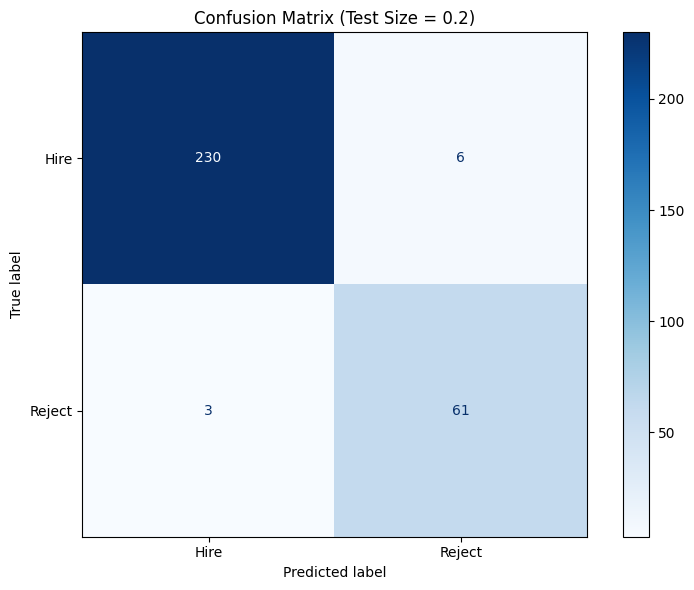

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# --- Confusion Matrix for test_size = 0.2 ---
print("Generating Confusion Matrix for test_size = 0.2")
# Reuse X_test_cb and y_test_cb from the 0.2 split (from cell 4d002348 onwards)
# Reuse y_pred_cb from the 0.2 split (from cell 5b4badcf)

cm_0_2 = confusion_matrix(y_test_cb, y_pred_cb, labels=cat_model.classes_)
disp_0_2 = ConfusionMatrixDisplay(confusion_matrix=cm_0_2, display_labels=cat_model.classes_)

fig_0_2, ax_0_2 = plt.subplots(figsize=(8, 6))
disp_0_2.plot(cmap=plt.cm.Blues, ax=ax_0_2)
ax_0_2.set_title('Confusion Matrix (Test Size = 0.2)')
plt.tight_layout()
plt.show()

Generating Confusion Matrix for test_size = 0.3


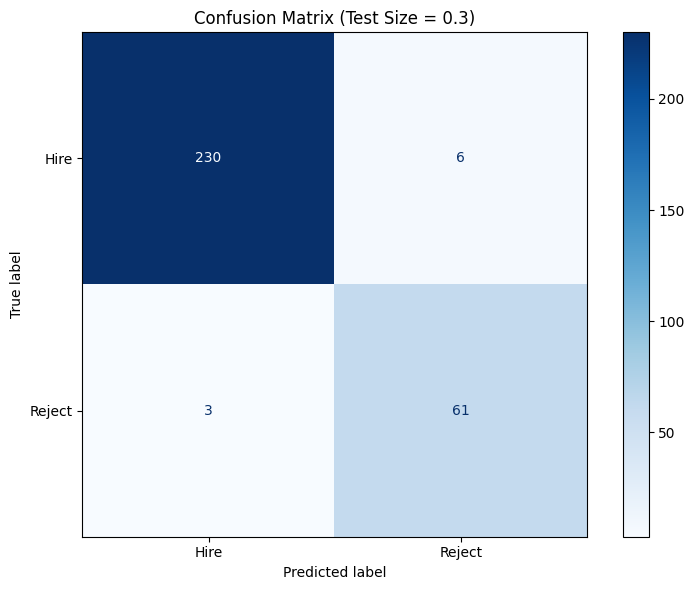

In [31]:
# --- Confusion Matrix for test_size = 0.3 ---
print("Generating Confusion Matrix for test_size = 0.3")
# X_train_cb, X_test_cb, y_train_cb, y_test_cb from cell 'pkCTPh2Vaktn' are for 0.3 split
# y_pred_cb from cell '1LX5QjMkak0O' are predictions for 0.3 split

# Note: The variables X_test_cb, y_test_cb, y_pred_cb were overwritten by the last 0.2 test_size execution.
# To correctly plot for 0.3 test size, we need to re-run the 0.3 split and prediction steps.
# Let's redefine X_test_cb, y_test_cb, y_pred_cb for the 0.3 split directly here.

from sklearn.model_selection import train_test_split

# Re-split for 0.3 test size
X_train_cb_03, X_test_cb_03, y_train_cb_03, y_test_cb_03 = train_test_split(
    X_catboost, Y, test_size=0.3, random_state=42
)

# Re-train and predict for 0.3 test size
cat_model_03 = CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    loss_function='Logloss',
    eval_metric='Accuracy',
    random_seed=42,
    verbose=False,
    cat_features=categorical_features_indices
)
cat_model_03.fit(X_train_cb_03, y_train_cb_03)
y_pred_cb_03 = cat_model_03.predict(X_test_cb_03)

cm_0_3 = confusion_matrix(y_test_cb_03, y_pred_cb_03, labels=cat_model_03.classes_)
disp_0_3 = ConfusionMatrixDisplay(confusion_matrix=cm_0_3, display_labels=cat_model_03.classes_)

fig_0_3, ax_0_3 = plt.subplots(figsize=(8, 6))
disp_0_3.plot(cmap=plt.cm.Blues, ax=ax_0_3)
ax_0_3.set_title('Confusion Matrix (Test Size = 0.3)')
plt.tight_layout()
plt.show()